In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/CMPE 401/Instructor Defined 1/baseline_yolo11s"

Mounted at /content/drive


## **Part III: Structured Experimental Design**

### Experimental Settings

This experiment investigates the effect of **model size** on object detection performance using the VisDrone dataset.
Model size was chosen as the variable because the Part I baseline (YOLOv11n) showed limited performance across smaller and less frequent classes, suggesting the nano model may not have enough capacity to learn all 10 classes effectively.

All other settings were kept identical to the baseline to ensure a fair and controlled comparison:

| Setting | Baseline (YOLOv11n) | Experiment (YOLOv11s) |
|---|---|---|
| Dataset | VisDrone2019 | VisDrone2019 |
| Image Size | 640 | 640 |
| Batch Size | 16 | 16 |
| Max Epochs | 200 | 200 |
| Patience | 50 | 50 |
| **Model** | **YOLOv11n** | **YOLOv11s** |

The only change between the two runs is the model variant: YOLOv11n (nano) vs YOLOv11s (small).
YOLOv11s has more parameters and greater representational capacity than YOLOv11n, which should allow it to learn more complex features and potentially improve detection across all classes.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_path = f"{BASE}/results.csv"

df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()

# final epoch metrics
final = df.iloc[-1]
print("=== Final Epoch Results ===")
print(f"mAP@50:        {final['metrics/mAP50(B)']:.4f}")
print(f"mAP@50-95:     {final['metrics/mAP50-95(B)']:.4f}")
print(f"Precision:     {final['metrics/precision(B)']:.4f}")
print(f"Recall:        {final['metrics/recall(B)']:.4f}")
print(f"Train Box Loss:{final['train/box_loss']:.4f}")
print(f"Val Box Loss:  {final['val/box_loss']:.4f}")

=== Final Epoch Results ===
mAP@50:        0.4135
mAP@50-95:     0.2456
Precision:     0.5294
Recall:        0.4014
Train Box Loss:1.1992
Val Box Loss:  1.3172


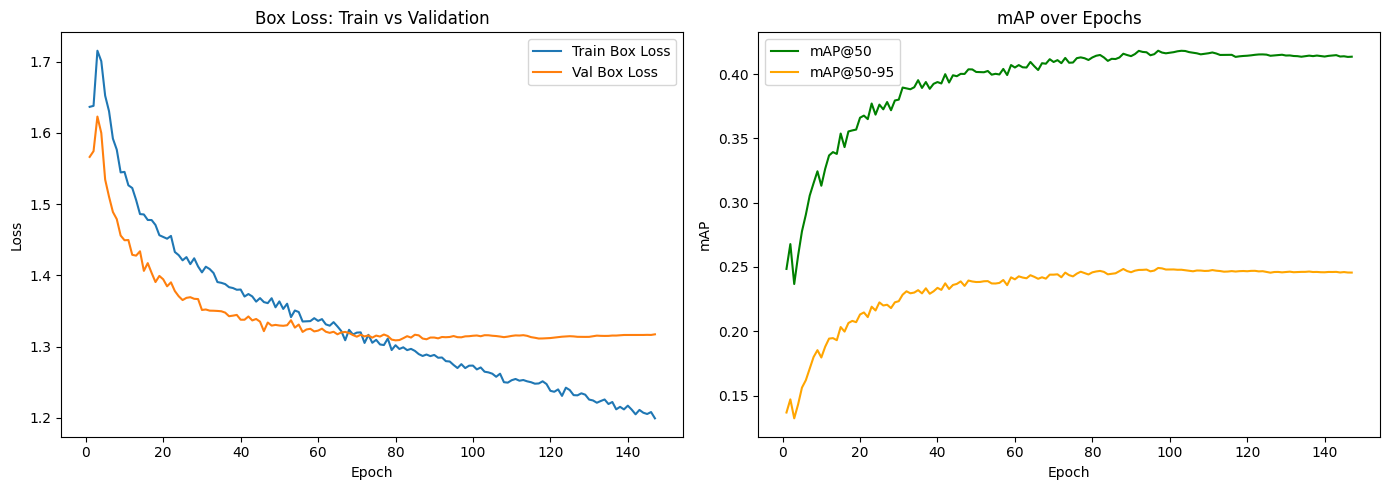

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
axes[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
axes[0].set_title('Box Loss: Train vs Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# mAP curve
axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green')
axes[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='orange')
axes[1].set_title('mAP over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mAP')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{BASE}/loss_map_curves.png", dpi=150)
plt.show()

In [ ]:
summary = {
    "Model": ["YOLOv11n"],
    "Epochs": [len(df)],
    "mAP@50": [round(final['metrics/mAP50(B)'], 4)],
    "mAP@50-95": [round(final['metrics/mAP50-95(B)'], 4)],
    "Precision": [round(final['metrics/precision(B)'], 4)],
    "Recall": [round(final['metrics/recall(B)'], 4)],
}
pd.DataFrame(summary)

,Model,Epochs,mAP@50,mAP@50-95,Precision,Recall
0,YOLOv11n,147,0.4135,0.2456,0.5294,0.4014


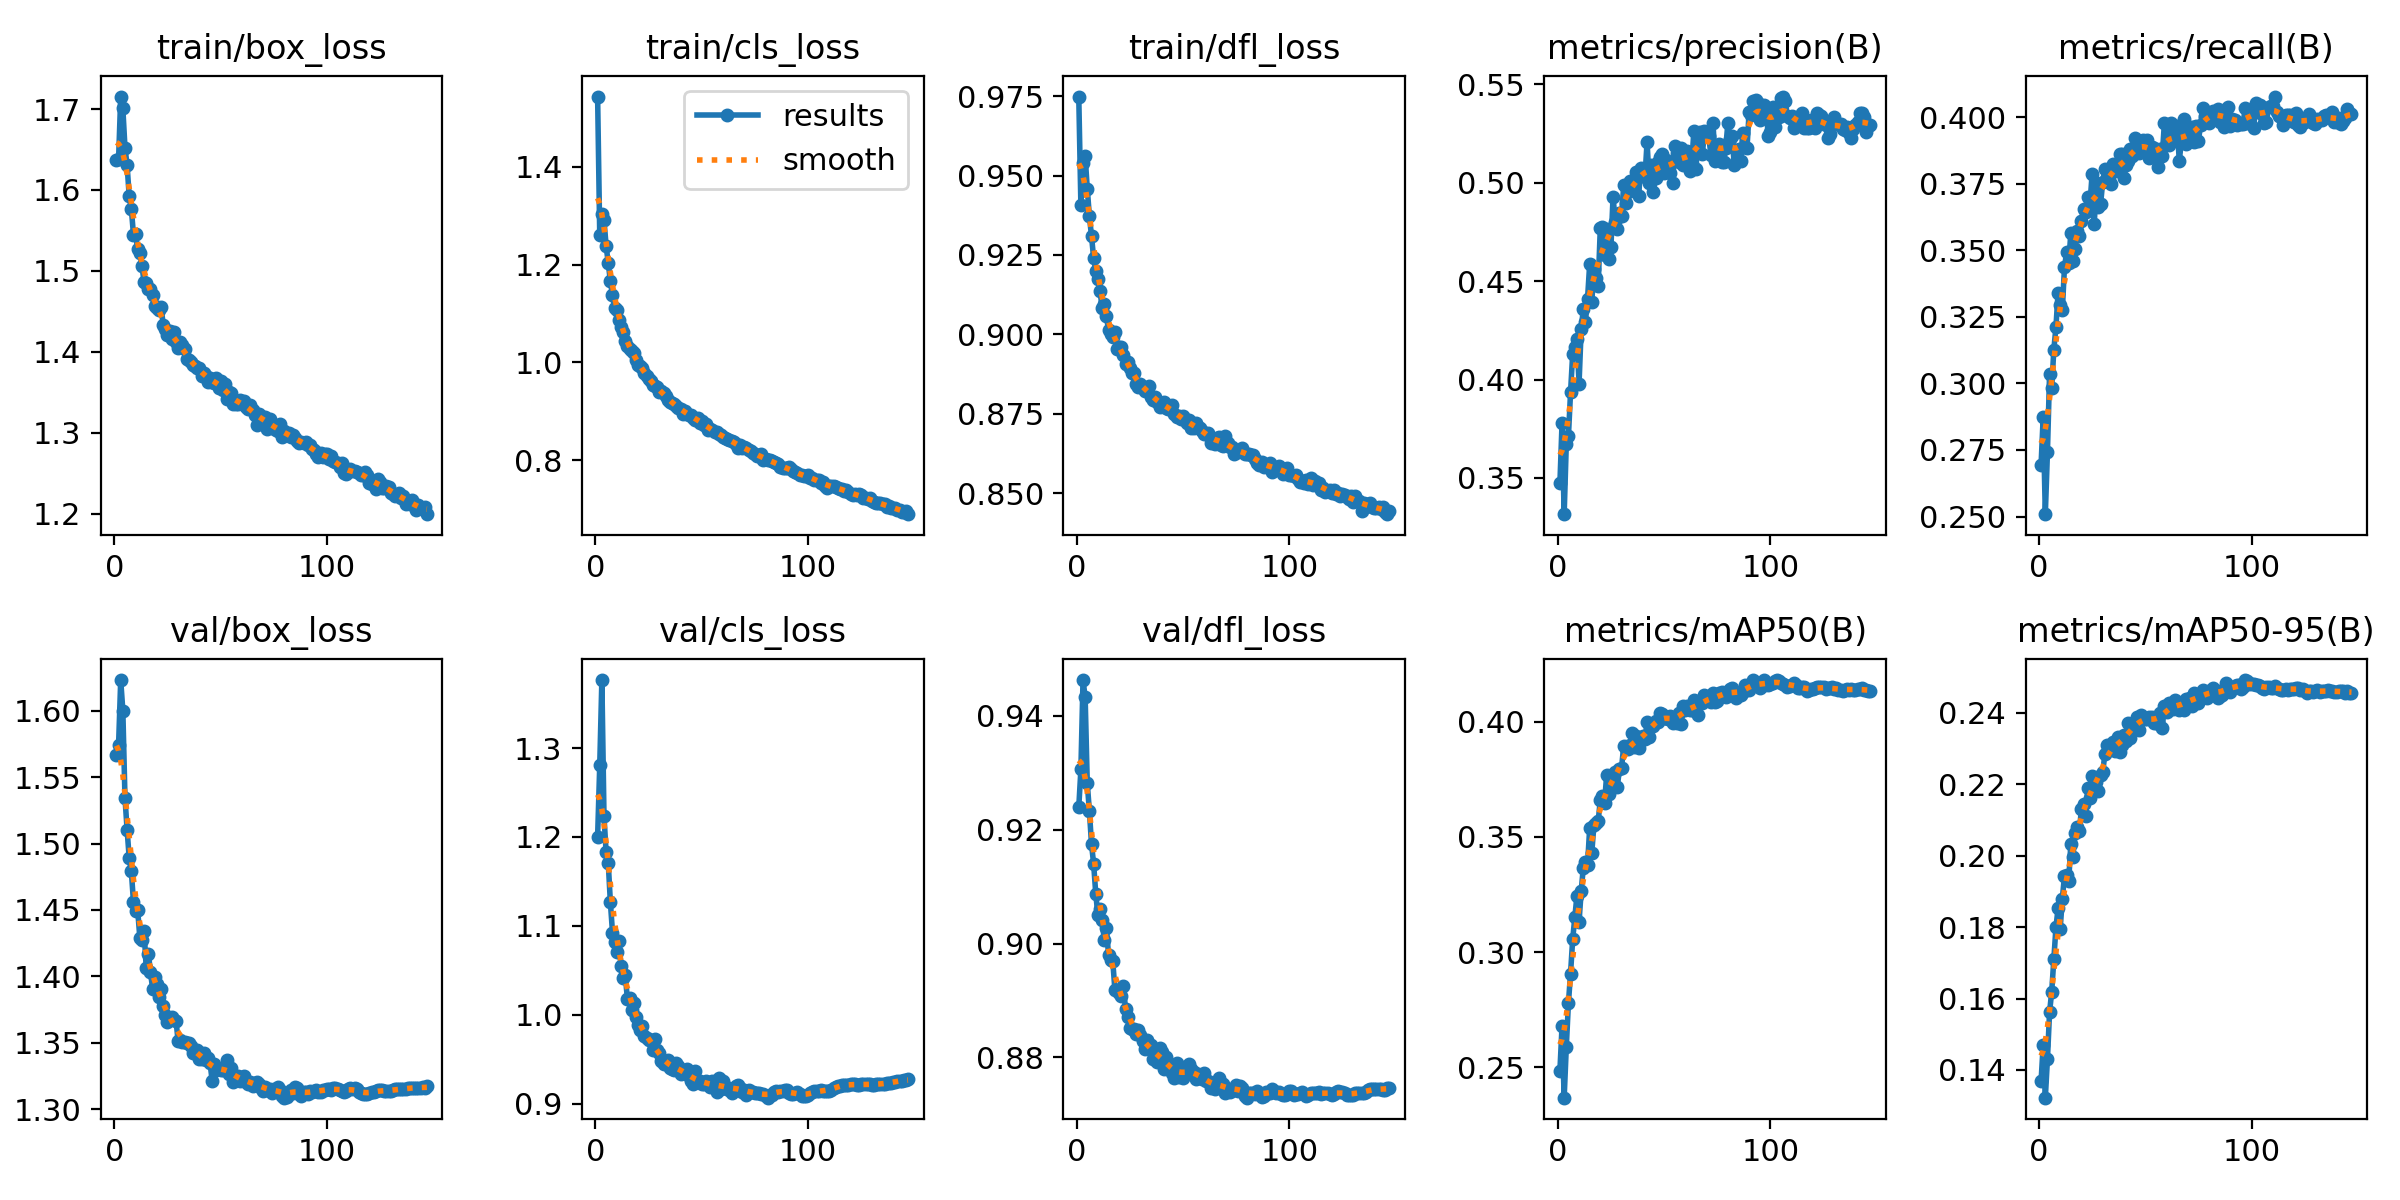

In [ ]:
from IPython.display import Image, display
display(Image(f"{BASE}/results.png"))

### **Discussion**

**Note:** 200 epochs were set with a patience of 50 during training. Early stopping triggered at epoch 147, meaning no improvement was observed in the last 50 epochs. The best model was saved as best.pt.

### 1. Training vs. Validation Loss

The loss curves above plot the **box loss** for both the training set and the validation set across all 147 epochs. The key observations are:

- Both curves descend steadily from the start of training, indicating the model is learning meaningful object detection features.
- After approximately epoch 80–100, both curves begin to slow down, with only small decreases in loss through the remaining epochs.
- At the final epoch (epoch 147), the **training box loss is 1.1992** and the **validation box loss is 1.3172**, a gap of roughly **0.118**.

### 2. Convergence Behavior

The model has **converged**. Convergence is visible because:
- Neither the training nor the validation loss shows meaningful improvement in the later epochs.
- The mAP@50 stabilizes around **0.41** and mAP@50-95 around **0.245**, with no upward trend continuing toward the end of training.
- Both curves are smooth and consistent without sudden spikes, suggesting stable gradient updates and appropriate learning rate scheduling.

Early stopping with patience=50 was enabled, and training stopped at epoch 147, confirming the model had genuinely converged and additional epochs would not have improved performance.

### 3. Results Curves (results.png)

The results.png panel shows all training and validation losses alongside precision, recall, mAP@50, and mAP@50-95 across all epochs.

All three training losses (box, cls, dfl) decrease consistently throughout training without divergence, indicating stable optimization.
The validation losses mirror this behavior but increase slightly earlier, which is a normal and healthy pattern.

Precision is noticeably noisy throughout training, fluctuating across epochs.
This is common in YOLO training because precision is threshold-sensitive, meaning small shifts in the confidence threshold during validation can cause visible swings in the metric.
The smoothed trend shows precision stabilizing around **0.52–0.53**, consistent with the final reported value of 0.5294.

Recall shows a steadier upward trend, gradually improving across training and settling around **0.40**.
Both mAP curves rise in the first half of training and then increase, confirming convergence.
The gap between mAP@50 (0.4135) and mAP@50-95 (0.2456) reflects that the model finds objects in roughly the right location but still struggles with tight bounding box localization, though this gap is slightly smaller than what was observed in the YOLOv11n baseline.

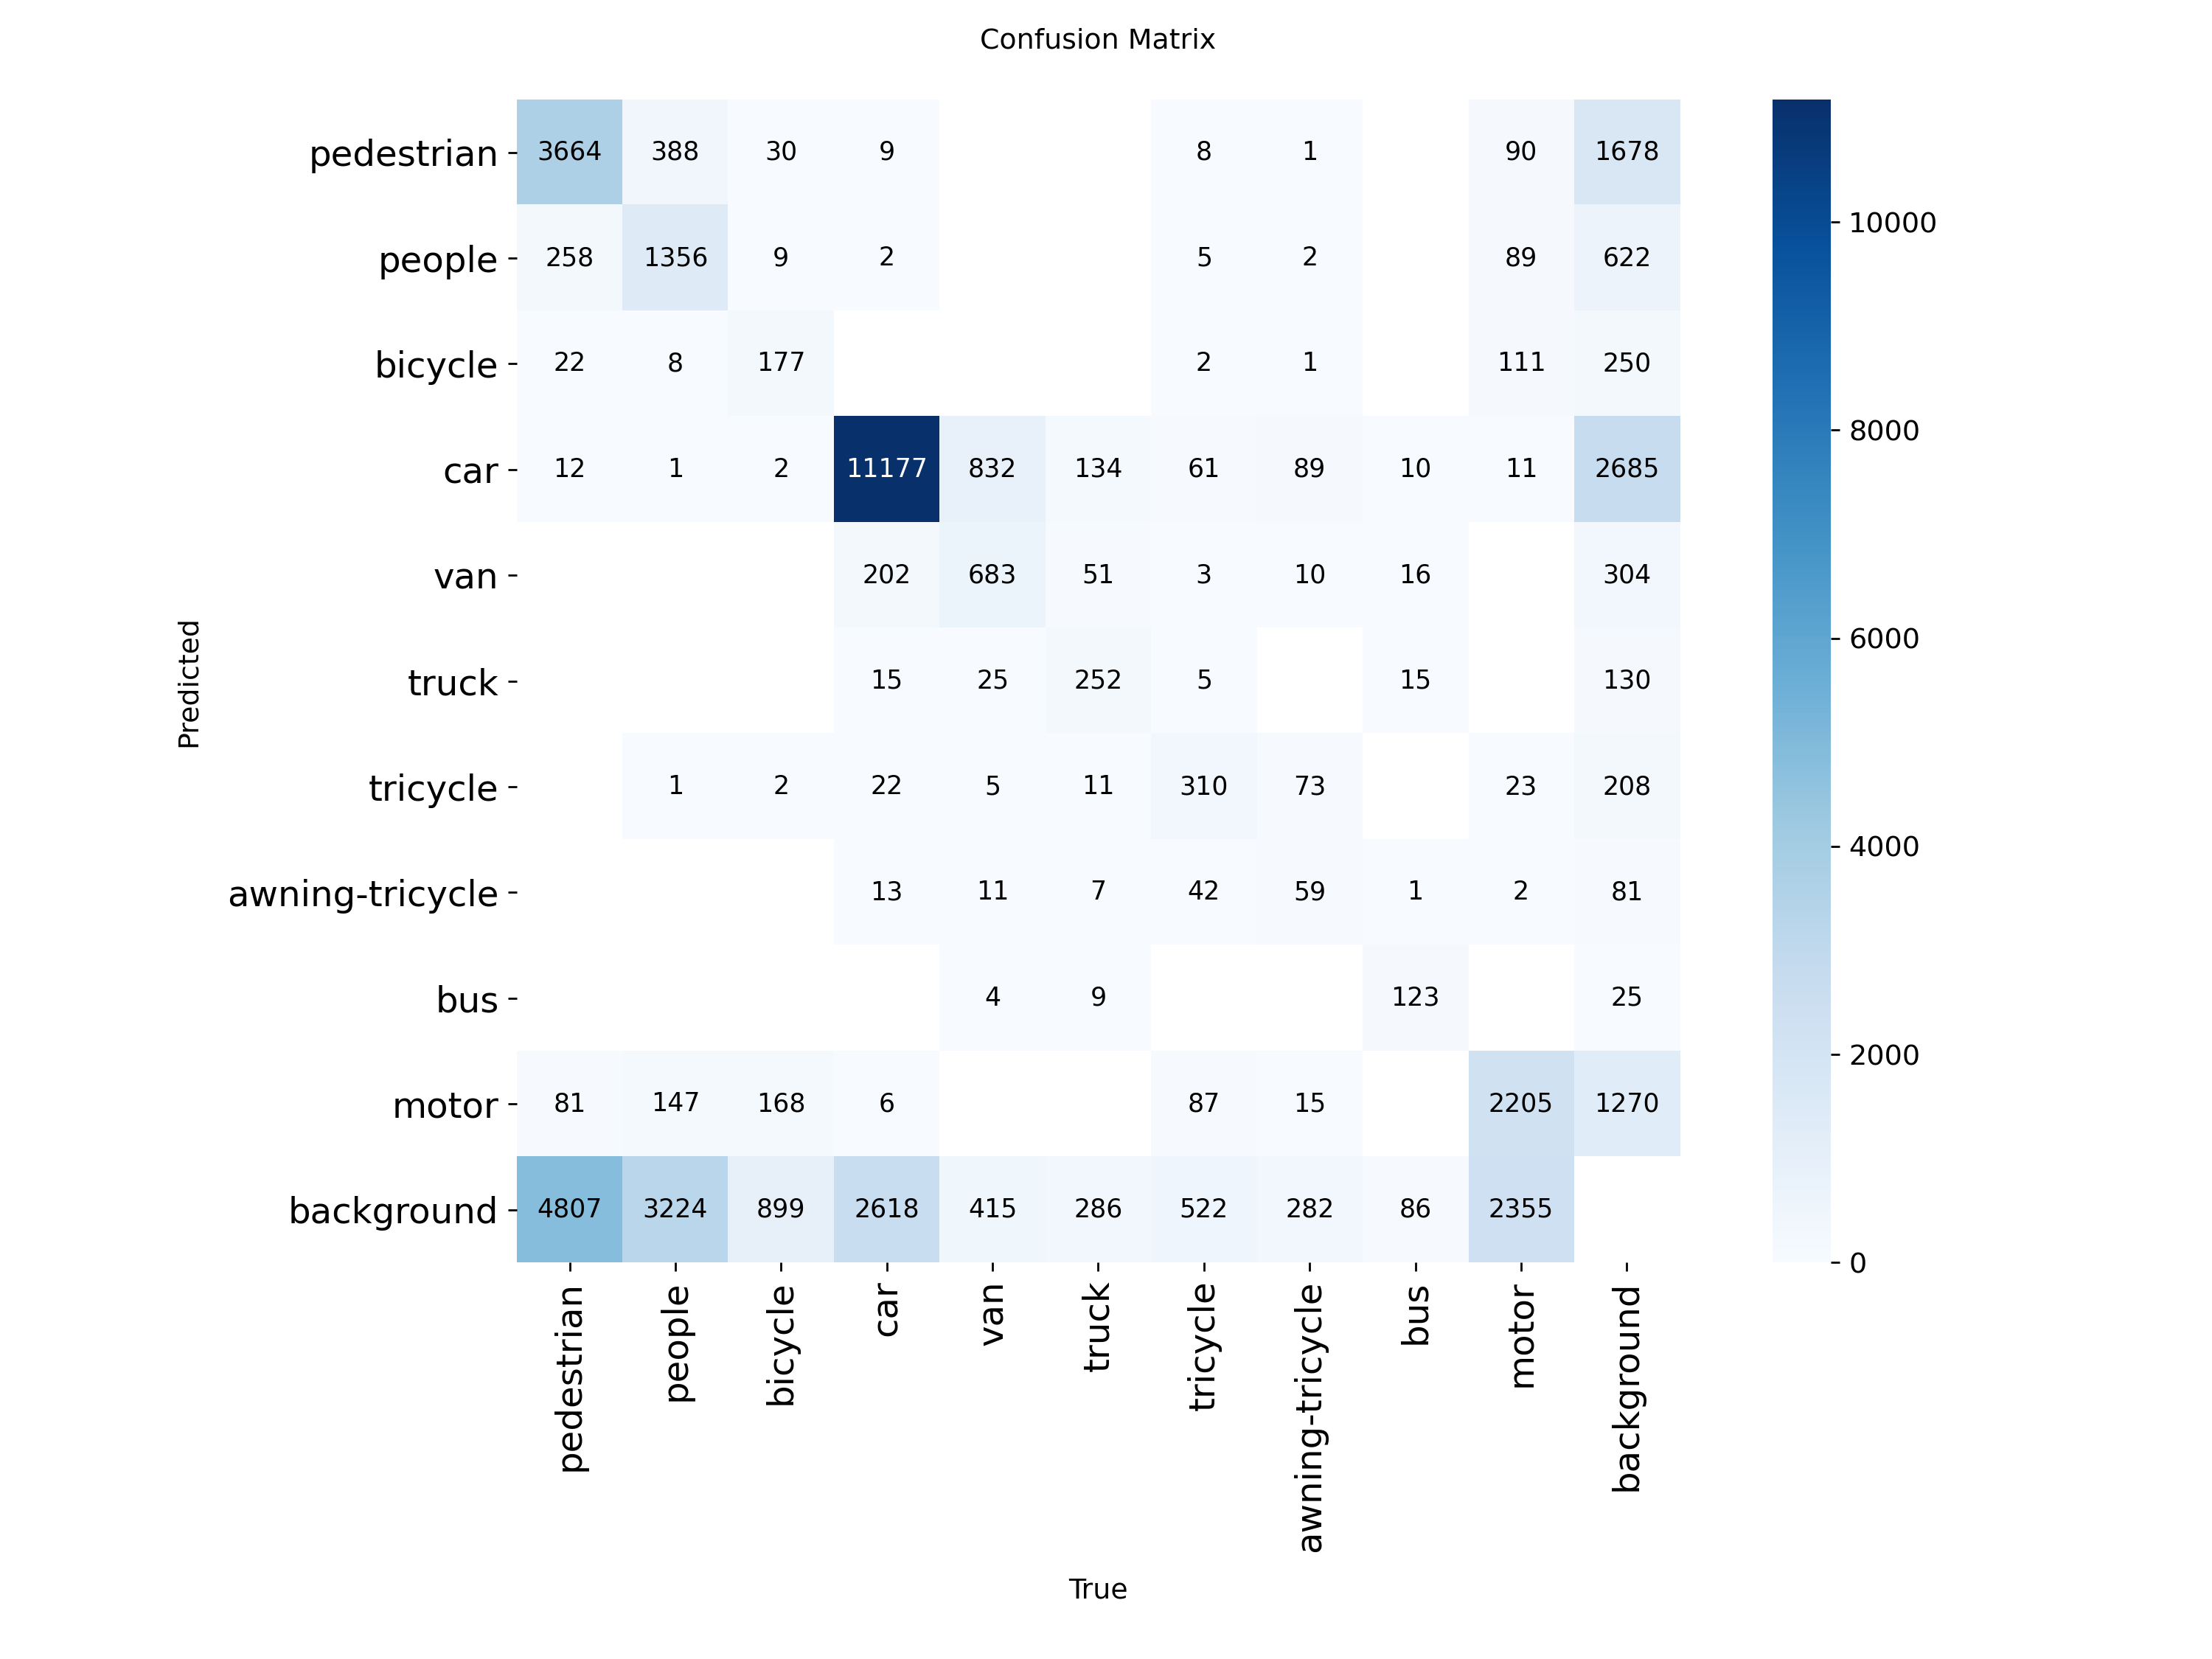

In [ ]:
display(Image(f"{BASE}/confusion_matrix.png"))

### **Discussion**

### 4. Confusion Matrix

The confusion matrix shows detections across **all 10 classes**, consistent with the baseline run.
The overall detection pattern is similar to YOLOv11n but with noticeably better coverage across more classes, which reflects the increased capacity of the YOLOv11s model.

**Car:**
Car remains the strongest performing class, which is expected given it has the highest number of instances in the validation set.
The model detects cars confidently with relatively few misclassifications, contributing the most to the overall mAP.

**Pedestrian and People:**
Both pedestrian and people show improved detections compared to the baseline, though cross-class confusion between the two remains present.
This is expected since both classes describe human figures and are visually similar, especially at the small scales typical of drone imagery.
The rate of instances being suppressed as background has decreased compared to YOLOv11n, contributing to the improvement in recall from 0.3467 to 0.4014.

**Bicycle, Tricycle, and Awning-Tricycle:**
These classes still show the weakest detection performance among all classes.
They are small, infrequent objects that are harder to distinguish at low resolution.
While YOLOv11s shows some improvement over YOLOv11n for these classes, the gains are limited, suggesting that dataset size for these classes is a bigger bottleneck than model capacity alone.

**Bus and Van:**
Bus and van show improved detection performance compared to the baseline.
Van is still occasionally confused with car or truck due to visual similarity in shape and size, which is a common challenge in vehicle detection.

**Overall:**
The biggest issue shown in the confusion matrix is that the model still misses a lot of objects across most classes, incorrectly labeling them as background.
This is why recall (0.4014) is lower than precision (0.5294).
When the model does make a detection it tends to be correct, but it still fails to detect a large portion of the objects that are actually there.
That said, both precision and recall have improved compared to YOLOv11n (0.4472 and 0.3467 respectively), confirming that the larger model does help.

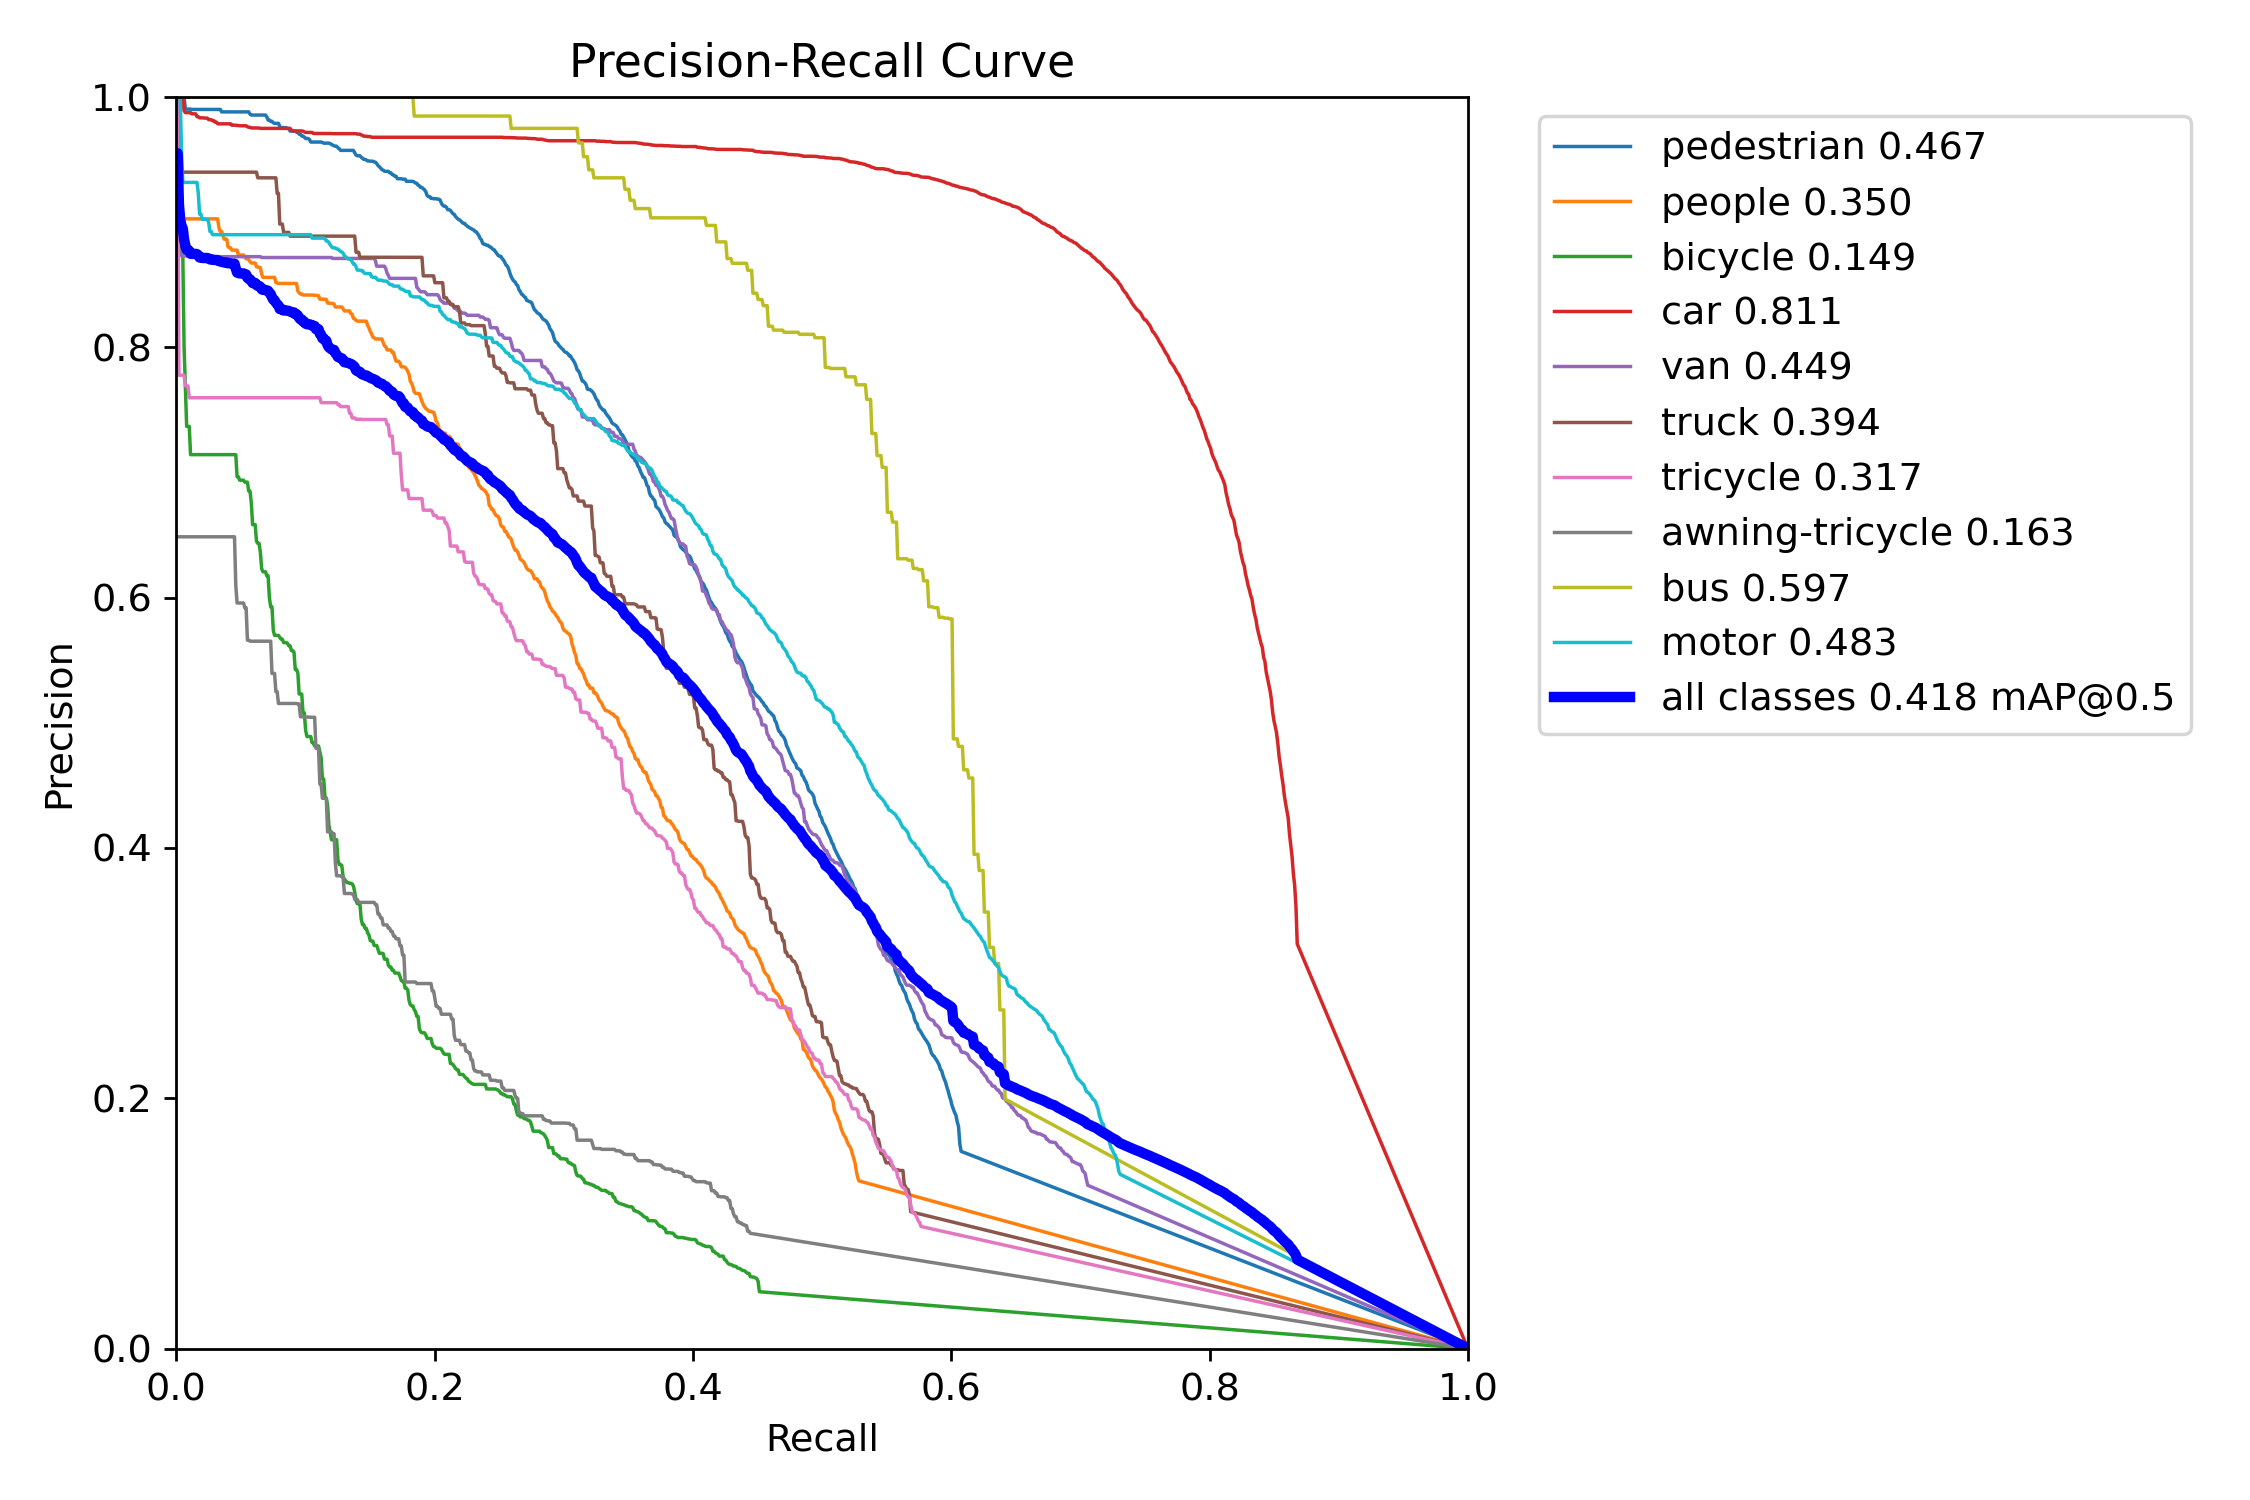

In [ ]:
display(Image(f"{BASE}/BoxPR_curve.png"))

### 5. PR Curve (Precision Recall Curve)

The PR curve plots precision against recall at varying confidence thresholds for each class, with the area under each curve representing the per-class average precision.

**Car** has the strongest PR curve, maintaining high precision across a wide range of recall values.
This is consistent with car being the most represented class in the dataset and the model's strongest performer.

**Motor and Bus** show decent performance compared to the weaker classes, with precision staying fairly consistent at lower recall thresholds before starting to drop.
These classes appear often enough in the dataset that the model was able to pick up on their features reasonably well.

**Pedestrian and People** both show curves that start dropping in precision earlier than car and motor.
This is likely because pedestrian and people look very similar to each other, especially in drone footage where objects appear small.
As the model tries to detect more instances of each class, it starts confusing the two with each other, which causes precision to fall faster.

**Bicycle, Tricycle, and Awning-Tricycle** have the weakest curves, dropping steeply even at low recall values.
These are small, infrequent objects that the model struggles to detect reliably.
Even when the confidence threshold is lowered to try to catch more of these objects, the model ends up making a lot of wrong detections, meaning precision drops quickly.

The overall **mAP@50 of 0.4135** is the average across all 10 classes, which is an improvement over the YOLOv11n baseline (0.3494).
Model performance is still uneven across classes, improving detection for the smaller and less frequent objects would have the biggest impact on overall mAP.

### **Discussion Summary**

### 6. Overfitting Analysis

There is **mild to moderate overfitting** present in this run. Evidence:
- The final training loss (1.1992) is noticeably lower than the validation loss (1.3172), a gap of approximately **0.118**.
- This gap is larger than what was observed in the YOLOv11n baseline (~0.025), which is expected. YOLOv11s has more parameters and therefore a greater tendency to overfit when the dataset size remains the same.
- The two curves still track each other in the early epochs but diverge more in the later stages of training.

**Possible Causes of overfitting in this experiment:**
- **Increased model capacity**: YOLOv11s has significantly more parameters than YOLOv11n. With the same dataset size, this gives the model more freedom to fit training-specific patterns rather than generalizable features.
- **Dataset size**: The dataset size did not change between experiments. A larger model trained on the same data is more susceptible to overfitting, which is reflected in the wider train/val gap.

### 7. Underfitting Analysis

The model does **not exhibit underfitting**. The loss curves show clear, sustained descent and mAP improved meaningfully compared to the baseline, showing the model successfully learned to detect objects across all 10 classes.

The mAP@50 of 0.4135 and recall of 0.4014 reflect a performance ceiling imposed by dataset size rather than a failure to learn.
The model learned effectively within its constraints, but further improvement would require more training data or techniques to address the class imbalance.

### 8. Causes: Dataset Size and Model Capacity

**Dataset Size:**

The size of the training dataset plays a big role in how well the model can learn and generalize. When the dataset is small, the model has fewer examples to learn from, which increases the chance of overfitting because it may start memorizing the training images instead of learning general features. It also means the model gets less exposure to different object appearances, angles, and lighting conditions, which limits how well it can handle unseen images during validation.

Even with a good model, performance is ultimately limited by what the training data covers. If certain classes or scenarios are underrepresented, the model simply will not learn them well, as seen with the weaker classes in our confusion matrix.

While data augmentation techniques such as flipping, scaling, mosaic, and color jitter are applied by default in Ultralytics YOLO and do help the model see more variation, they are not a full replacement for having more real annotated images. Collecting and labeling more data, especially for the weaker classes, would likely lead to noticeable improvements in both recall and mAP.

**Model Capacity:**

YOLOv11s is the small variant of the YOLOv11 family, one step up from the nano model used in the baseline. It has more parameters and greater representational capacity, which allowed it to learn more complex detection features and achieve better results across all metrics. However, the increased capacity also comes with a higher risk of overfitting when the dataset size stays the same, which is reflected in the larger train/val loss gap compared to YOLOv11n.

If higher accuracy is needed, a larger model variant such as YOLOv11m could be explored, though this would require even more data to avoid overfitting.

In [ ]:
summary = {
    "Model": ["YOLOv11n"],
    "Epochs": [len(df)],
    "mAP@50": [round(final['metrics/mAP50(B)'], 4)],
    "mAP@50-95": [round(final['metrics/mAP50-95(B)'], 4)],
    "Precision": [round(final['metrics/precision(B)'], 4)],
    "Recall": [round(final['metrics/recall(B)'], 4)],
}
pd.DataFrame(summary)

,Model,Epochs,mAP@50,mAP@50-95,Precision,Recall
0,YOLOv11n,147,0.4135,0.2456,0.5294,0.4014


**Summary Table:**

| Observation | What Was Seen | Possible Reason |
|---|---|---|
| Mild to moderate overfitting | Validation loss is higher than training loss (gap ~0.118) | Larger model capacity relative to the same dataset size increases tendency to overfit |
| Model converged before epoch 200 | Both losses stopped improving and early stopping triggered at epoch 147 | Learning rate scheduling slowed updates and the model had learned most of what the dataset could offer |
| Improved mAP@50 (~0.41 vs 0.35) | The larger model achieved better detection performance across all classes | YOLOv11s has more parameters and can learn more complex features than YOLOv11n |
| Improved recall (0.40 vs 0.35) | The model detected more true objects compared to the baseline | Increased model capacity helped reduce the rate of false negatives |

### **Part IV — Suggested Improvement**

Based on the results of this experiment, the most notable issue is the **increased overfitting** observed in YOLOv11s compared to YOLOv11n, as shown by the wider train/val loss gap (~0.118 vs ~0.025).
This is a direct consequence of using a larger model on the same dataset without any regularization.

For Part IV, the proposed improvement is to apply **weight decay (L2 regularization)** to the YOLOv11s training run. Weight decay penalizes large parameter values during training, which discourages the model from overfitting to the training data and should help close the gap between training and validation loss.

This is a theory-driven choice grounded in what the Part III results showed. The model has the capacity to perform well, but needs regularization to generalize better to unseen data.